In [1]:
# coding: utf-8
# наше всё
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from pylab import rcParams

# настройки pandas, с которыми лучше почти всегда
pd.set_option('display.max_rows', 45000)
pd.set_option('display.max_columns', 50000)
pd.set_option('display.max_colwidth', 5000)

# графики в svg выглядят более четкими
%config InlineBackend.figure_format = 'svg' 
rcParams['figure.figsize'] = 16, 12

In [2]:
source_df = pd.read_excel('qval2.xlsx', sheet_name='Worksheet')

In [3]:
res_df = source_df.copy()
diff_df = res_df.copy()
for i in range(1, len(diff_df.columns)-2):
    diff_df[i] = np.sum(diff_df[i]) / len(diff_df[i])



pot_df = res_df.copy()
for i in range(1, len(diff_df.columns)-2):
    pot_df[i] = diff_df[i] * res_df[i]


diff_df = diff_df[0:1][diff_df.columns[3:]].T
diff_df = diff_df.reset_index()
diff_df.columns = ['question', 'difficulty']


In [4]:
diff_df.sample(3)

,question,difficulty
8,9,0.772727
20,21,0.363636
4,5,0.181818


In [5]:
diff_df.sort_values(by='difficulty', ascending=False)[0:3]

,question,difficulty
27,28,0.954545
35,36,0.863636
12,13,0.818182


In [6]:
diff_df.sort_values(by='difficulty', ascending=True)[0:3]

,question,difficulty
9,10,0.000000
1,2,0.045455
34,35,0.045455


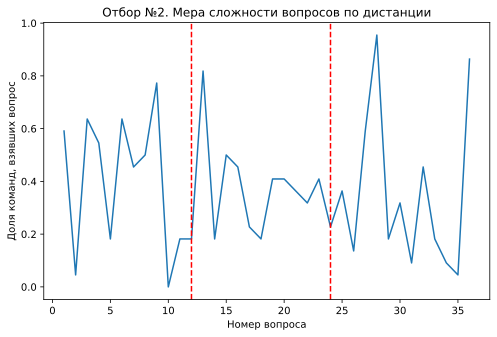

In [7]:
plt.figure(figsize=(8, 5))
sns.lineplot(data=diff_df, x='question', y='difficulty')
plt.xlabel('Номер вопроса')
plt.ylabel('Доля команд, взявших вопрос')
plt.title('Отбор №2. Мера сложности вопросов по дистанции')
#  вертикальная линия при x = 12 и x = 24
plt.axvline(x=12, color='red', linestyle='--')
plt.axvline(x=24, color='red', linestyle='--')
plt.show()


<Figure size 800x500 with 0 Axes>

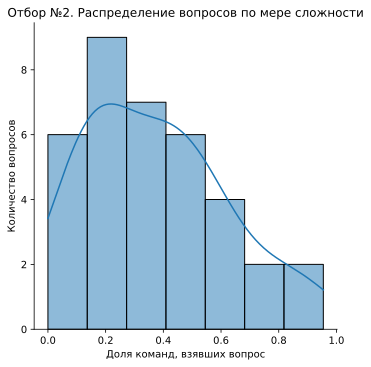

In [8]:
plt.figure(figsize=(8, 5))
sns.displot(diff_df['difficulty'], kde=True)
plt.xlabel('Доля команд, взявших вопрос')
plt.ylabel('Количество вопросов')
plt.title('Отбор №2. Распределение вопросов по мере сложности')
plt.show()






In [9]:
team_stat = res_df[res_df.columns[0:3]].copy()
team_stat['result'] = np.sum(res_df[res_df.columns[3:]], axis=1)
team_stat['difficulty'] = np.sum(pot_df[pot_df.columns[3:]], axis=1)
team_stat['potential'] = team_stat['difficulty'] / team_stat['result']


In [10]:
team_stat.sort_values(by='result', ascending=False)

,Team ID,Название,Город,result,difficulty,potential
8,74852,Сурок богоугодности,Москва,30,12.954545,0.431818
15,98861,Которая не в Паттайе,Москва,27,10.681818,0.395623
0,92064,Древние русы,Москва,17,9.727273,0.572193
6,100000,Олд Мани,Москва,17,9.136364,0.537433
1,104735,Диванные знатоки,Москва,17,8.818182,0.518717
5,104534,Пососсюр,Москва,16,7.818182,0.488636
11,107757,Олимпионики,Москва,16,8.090909,0.505682
9,107756,Приказ скифского царя,Москва,16,8.727273,0.545455
3,39048,Кот Бегемот,Москва,14,7.363636,0.525974
12,107758,Иногда ОКДФ,Москва,14,7.227273,0.516234


In [11]:
team_stat[['result']].describe()

,result
count,22.000000
mean,13.500000
std,6.292475
min,2.000000
25%,9.500000
50%,13.000000
75%,16.000000
max,30.000000


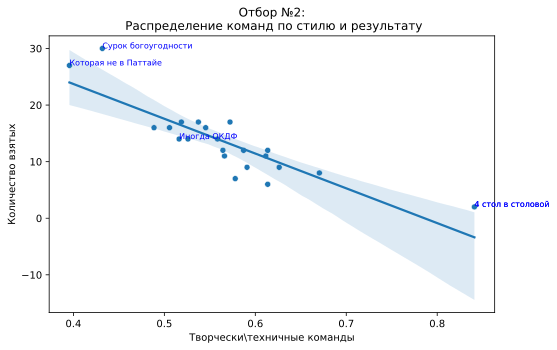

In [ ]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=team_stat, 
    x="potential", 
    y="result",
    )

plt.title("Отбор №2:\n Распределение команд по стилю и результату")
# add a trend line
sns.regplot(data=team_stat, x="potential", y="result", scatter=False)

# add points
x1 = np.min(team_stat['potential'])
y1 = team_stat[team_stat['potential'] == x1]['result'].values[0]
name1 = team_stat[team_stat['potential'] == x1]['Название'].values[0]
plt.text(x1, y1, name1, fontsize=8, color='blue')

x2 = np.max(team_stat['potential'])
y2 = team_stat[team_stat['potential'] == x2]['result'].values[0]
name2 = team_stat[team_stat['potential'] == x2]['Название'].values[0]
plt.text(x2, y2, name2, fontsize=8, color='blue')

y3 = np.max(team_stat['result'])
x3 = team_stat[team_stat['result'] == y3]['potential'].values[0]
name3 = team_stat[team_stat['result'] == y3]['Название'].values[0]
plt.text(x3, y3, name3, fontsize=8, color='blue')

y4 = np.min(team_stat['result'])
x4 = team_stat[team_stat['result'] == y4]['potential'].values[0]
name4 = team_stat[team_stat['result'] == y4]['Название'].values[0]
plt.text(x4, y4, name4, fontsize=8, color='blue')

x5 = team_stat['potential'].values[np.random.randint(0, len(team_stat))]
y5 = team_stat[team_stat['potential'] == x5]['result'].values[0]
name5 = team_stat[team_stat['potential'] == x5]['Название'].values[0]
plt.text(x5, y5, name5, fontsize=8, color='blue')

plt.xlabel("Творчески\техничные команды")
plt.ylabel("Количество взятых")

plt.show()


In [13]:
# сильные техничные команды
team_stat[
    (team_stat['potential'] > np.mean(team_stat['potential'])) & 
    (team_stat['result'] > np.mean(team_stat['result']))
]['Название']

0    Древние русы
Name: Название, dtype: object

In [14]:
# сильные творческие команды
team_stat[
    (team_stat['potential'] < np.mean(team_stat['potential'])) & 
    (team_stat['result'] > np.mean(team_stat['result']))
]['Название']

1          Диванные знатоки
3               Кот Бегемот
5                  Пососсюр
6                  Олд Мани
8       Сурок богоугодности
9     Приказ скифского царя
11              Олимпионики
12              Иногда ОКДФ
15     Которая не в Паттайе
21              О, леопард!
Name: Название, dtype: object

In [15]:
team_stat.sort_values(by='potential', ascending=True)[0:5]

,Team ID,Название,Город,result,difficulty,potential
15,98861,Которая не в Паттайе,Москва,27,10.681818,0.395623
8,74852,Сурок богоугодности,Москва,30,12.954545,0.431818
5,104534,Пососсюр,Москва,16,7.818182,0.488636
11,107757,Олимпионики,Москва,16,8.090909,0.505682
12,107758,Иногда ОКДФ,Москва,14,7.227273,0.516234


In [16]:
team_stat.sort_values(by='potential', ascending=False)[0:5]

,Team ID,Название,Город,result,difficulty,potential
4,98881,4 стол в столовой,Москва,2,1.681818,0.840909
16,69982,Друзья Друзя,Москва,8,5.363636,0.670455
19,107761,Братья Либери,Москва,9,5.636364,0.626263
7,107755,Радиоактивные люди,Москва,6,3.681818,0.613636
14,107759,Курица Въяйценко,Москва,12,7.363636,0.613636


In [17]:
team_qv_df = res_df.melt(
    id_vars=['Название', 'Город', 'Team ID'],
    value_vars=res_df.columns[3:],
    var_name='question',
    value_name='qv_result'
)
team_qv_df = team_qv_df.merge(
    diff_df, 
    'left',
    on='question'
)
team_qv_df = team_qv_df.merge(
    team_stat,
    'left',
    on=['Название', 'Team ID', 'Город'],
    suffixes=('_qv', '_total')
)
team_qv_df['epic'] = team_qv_df['result'] * team_qv_df['difficulty_qv']




In [18]:
# топ эпических взятий
team_qv_df[team_qv_df['qv_result'] == 1].sort_values(by='epic', ascending=True)[0:3]

,Название,Город,Team ID,question,qv_result,difficulty_qv,result,difficulty_total,potential,epic
667,Радиоактивные люди,Москва,107755,31,1,0.090909,6,3.681818,0.613636,0.545455
39,Либери Пабаджи,Москва,107760,2,1,0.045455,12,6.772727,0.564394,0.545455
634,Смех не грех,Москва,107736,29,1,0.181818,7,4.045455,0.577922,1.272727


In [19]:
# топ эпических продолбов
team_qv_df[team_qv_df['qv_result'] == 0].sort_values(by='epic', ascending=False)[0:4]

,Название,Город,Team ID,question,qv_result,difficulty_qv,result,difficulty_total,potential,epic
785,Которая не в Паттайе,Москва,98861,36,0,0.863636,27,10.681818,0.395623,23.318182
59,Которая не в Паттайе,Москва,98861,3,0,0.636364,27,10.681818,0.395623,17.181818
270,Олд Мани,Москва,100000,13,0,0.818182,17,9.136364,0.537433,13.909091
275,Олимпионики,Москва,107757,13,0,0.818182,16,8.090909,0.505682,13.090909


In [20]:
res_df = res_df.merge(
    team_stat,
    'left',
    on=['Название', 'Team ID', 'Город'],
    suffixes=('_qv', '_total')
)
res_df.sample(3)


,Team ID,Название,Город,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,result,difficulty,potential
13,107544,Тамбовский Волк,Москва,1,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,1,0,0,0,1,1,0,1,1,0,0,0,0,0,0,0,1,11,6.227273,0.566116
8,74852,Сурок богоугодности,Москва,1,0,1,1,1,1,1,1,1,0,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,1,1,1,0,1,1,0,1,1,30,12.954545,0.431818
11,107757,Олимпионики,Москва,1,0,1,0,0,1,1,0,1,0,0,1,0,0,0,1,1,0,1,1,0,0,0,0,1,0,1,1,0,0,0,1,0,1,0,1,16,8.090909,0.505682


In [21]:
# корреляция между столбцам в data frame
correlations_with_result = pd.DataFrame(res_df[res_df.columns[3:-2]].corr()['result'])
correlations_with_result.columns = ['correlation']
correlations_with_result.sort_values(by='correlation', ascending=False)[0:7]

,correlation
result,1.000000
11,0.651768
33,0.651768
17,0.643967
27,0.639111
14,0.632598
25,0.599426


In [22]:
correlations_with_result.sort_values(by='correlation', ascending=True)[0:5]

,correlation
36,-0.161586
13,-0.076679
2,-0.053243
31,0.154313
24,0.167608


In [23]:
res_df.sample(3)

,Team ID,Название,Город,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,result,difficulty,potential
14,107759,Курица Въяйценко,Москва,1,0,1,0,0,1,0,0,1,0,0,0,1,0,1,1,0,0,1,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,12,7.363636,0.613636
5,104534,Пососсюр,Москва,1,0,0,0,0,0,0,1,1,0,0,1,1,1,1,1,0,0,0,0,1,1,0,1,1,1,1,1,0,0,0,0,0,0,0,1,16,7.818182,0.488636
10,54223,Минута Молчания,Москва,1,0,1,0,1,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,0,1,0,0,0,1,11,6.727273,0.611570


In [24]:
top_3 = list(correlations_with_result.sort_values(by='correlation', ascending=False)[1:4].index)
top_5 = list(correlations_with_result.sort_values(by='correlation', ascending=False)[1:6].index)

In [25]:
res_df['top-3'] = np.sum(res_df[res_df.columns[res_df.columns.isin(top_3)]], axis=1)
res_df['top-5'] = np.sum(res_df[res_df.columns[res_df.columns.isin(top_5)]], axis=1)
res_df.sample(3)






,Team ID,Название,Город,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,result,difficulty,potential,top-3,top-5
8,74852,Сурок богоугодности,Москва,1,0,1,1,1,1,1,1,1,0,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,1,1,1,0,1,1,0,1,1,30,12.954545,0.431818,3,5
18,107736,Смех не грех,Москва,1,0,0,1,0,0,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,7,4.045455,0.577922,0,0
6,100000,Олд Мани,Москва,1,0,1,1,0,1,1,0,1,0,0,1,0,0,1,1,0,0,1,0,1,1,1,0,0,0,1,1,0,0,0,1,0,0,0,1,17,9.136364,0.537433,0,1


In [26]:
res_df[['top-3', 'top-5', 'result']].corr()

,top-3,top-5,result
top-3,1.000000,0.907532,0.720226
top-5,0.907532,1.000000,0.856705
result,0.720226,0.856705,1.000000
